In [1]:
import torch
import gpytorch
import numpy as np
from scipy.io import loadmat
from gpytorch.kernels import Kernel
from gpytorch.models import ExactGP
from gpytorch.likelihoods import MultitaskGaussianLikelihood
from gpytorch.kernels import MultitaskKernel, IndexKernel, LinearKernel, RBFKernel
from gpytorch.mlls import ExactMarginalLogLikelihood
import matplotlib.pyplot as plt

In [2]:
## define the MT GPR model
# The model is a Gaussian Process with a Multitask kernel and a Multitask likelihood.
# The Multitask kernel allows for the modeling of multiple related tasks, while the Multitask likelihood
# allows for the modeling of multiple outputs with correlated noise.
# The model is trained using the maximum likelihood estimation (MLE) method.
# The model is defined as a subclass of the gpytorch.models.ExactGP class, which is a base class for Gaussian Process models.
class MultiTaskGPModel_RBF(ExactGP):
    def __init__(self, train_x, train_y, likelihood, num_tasks):
        super().__init__(train_x, train_y, likelihood)
        self.num_tasks = num_tasks

        # Define the input-space kernel: Linear Kernel
        # input_kernel = LinearKernel(), CosineSimilarityKernel()

        # Define the multitask kernel
        self.covar_module = MultitaskKernel(
            RBFKernel(), 
            num_tasks = num_tasks,
            rank=1  # Rank defines the task interaction complexity
        )

        # Define the mean module
        self.mean_module = gpytorch.means.MultitaskMean(
            gpytorch.means.ConstantMean(),
            num_tasks=num_tasks
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)

In [3]:
# define the training impacts and sensors indices 
train_idx = np.arange(0, 35)
sensor_idx = np.arange(0, 6)
case = "TEM"

In [4]:
#### Load the reference training data 
# Load TDOAs, implocs, and senlocs from the 'REF.mat' file
TDOAs = loadmat('TDOA_REF.mat')['TDOAs']
implocs = loadmat('TDOA_REF.mat')['implocs']
senlocs = loadmat('TDOA_REF.mat')['senlocs']

# Convert TDOAs to a torch tensor and store the original version
X_train = torch.tensor(TDOAs, dtype=torch.float32)[train_idx, :]
X_train = X_train[:, sensor_idx]  # Select relevant sensors
X_train_ORI = torch.clone(X_train)

# Normalize X_train by its norm
X_train_SN = X_train / X_train.norm(dim=-1, keepdim=True)

# Calculate mean and standard deviation of X_train
X_train_mean = torch.mean(X_train, dim=0)
X_train_std = torch.std(X_train, dim=0)

# Normalize X_train using mean and standard deviation
X_train_FN = (X_train - X_train_mean) / X_train_std

# Convert implocs to a torch tensor and select training indices
y_train = torch.tensor(implocs, dtype=torch.float32)
y_train = y_train[train_idx, :]

# Store the original version of y_train
y_train_ORI = torch.clone(y_train)

# Calculate mean and standard deviation of y_train
y_train_mean = torch.mean(y_train, dim=0)
y_train_std = torch.std(y_train, dim=0)

# Normalize y_train using mean and standard deviation
y_train_FN = (y_train - y_train_mean) / y_train_std

In [5]:
#### Load the testing data from another impact case
# Load TDOAs, implocs, and senlocs from the specified case file
TDOAs = loadmat('TDOA_' + case + '.mat')['TDOAs']
implocs = loadmat('TDOA_' + case + '.mat')['implocs']
senlocs = loadmat('TDOA_' +  case + '.mat')['senlocs']

# Convert TDOAs to a torch tensor and store the original version
X_test = torch.tensor(TDOAs[:, sensor_idx], dtype=torch.float32)*2
X_test_ORI = torch.clone(X_test)

# Normalize X_test by its norm
X_test_SN = X_test / X_test.norm(dim=-1, keepdim=True)

# Normalize X_test using mean and standard deviation of X_train
X_test_FN = (X_test - X_train_mean) / X_train_std

# Convert implocs to a torch tensor and store the original version
y_test = torch.tensor(implocs, dtype=torch.float32)
y_test_ORI = torch.clone(y_test)

# Normalize y_test using mean and standard deviation of y_train
y_test_FN = (y_test - y_train_mean) / y_train_std

In [6]:
# select the training and testing data
X_train = torch.clone(X_train_SN)
y_train = torch.clone(y_train_ORI)
X_test = torch.clone(X_test_SN)
y_test = torch.clone(y_test_ORI)

In [7]:
##### model training and prediction
# Set the random seed for reproducibility
torch.manual_seed(0)
num_tasks = 2
training_iterations = 5000
# Define likelihood and model
likelihood = MultitaskGaussianLikelihood(num_tasks=num_tasks)
model = MultiTaskGPModel_RBF(X_train, y_train, likelihood, num_tasks=num_tasks)

# Train the model
model.train()
likelihood.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = ExactMarginalLogLikelihood(likelihood, model)
for i in range(training_iterations):
    optimizer.zero_grad()
    output = model(X_train)
    loss = -mll(output, y_train)
    loss.backward()
    if i%200 ==0:
        print(f"Iter {i + 1}/{training_iterations} - Loss: {loss.item():.3f}")
    optimizer.step()
 
# Switch to evaluation mode
model.eval()
likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = likelihood(model(X_test))
    mean = predictions.mean
    lower, upper = predictions.confidence_region()

# Print predictions
# print("Mean predictions:", mean.view(-1, num_tasks))
# print("Confidence intervals:", lower.view(-1, num_tasks), upper.view(-1, num_tasks))

Iter 1/5000 - Loss: 167.565
Iter 201/5000 - Loss: 12.985
Iter 401/5000 - Loss: 9.500
Iter 601/5000 - Loss: 8.028
Iter 801/5000 - Loss: 7.182
Iter 1001/5000 - Loss: 6.622
Iter 1201/5000 - Loss: 6.221
Iter 1401/5000 - Loss: 5.917
Iter 1601/5000 - Loss: 5.679
Iter 1801/5000 - Loss: 5.486
Iter 2001/5000 - Loss: 5.328
Iter 2201/5000 - Loss: 5.195
Iter 2401/5000 - Loss: 5.082
Iter 2601/5000 - Loss: 4.985
Iter 2801/5000 - Loss: 4.900
Iter 3001/5000 - Loss: 4.826
Iter 3201/5000 - Loss: 4.759
Iter 3401/5000 - Loss: 4.699
Iter 3601/5000 - Loss: 4.645
Iter 3801/5000 - Loss: 4.596
Iter 4001/5000 - Loss: 4.550
Iter 4201/5000 - Loss: 4.507
Iter 4401/5000 - Loss: 4.467
Iter 4601/5000 - Loss: 4.429
Iter 4801/5000 - Loss: 4.392


tensor([ 8.1996,  4.6972,  5.4443,  6.0541,  8.8003, 10.7257, 18.9935,  9.4946,
        10.0447, 13.2975,  8.9773,  7.1518,  6.3732,  4.6204, 14.5604,  9.7739,
        14.9082,  4.5861,  2.8491,  6.6791,  6.3450, 11.9976, 13.4024, 14.8557,
        10.0027,  7.0135, 10.1980,  6.0224, 22.1459, 13.9716,  6.6647,  2.2789,
         3.2453,  3.1976,  7.8596])


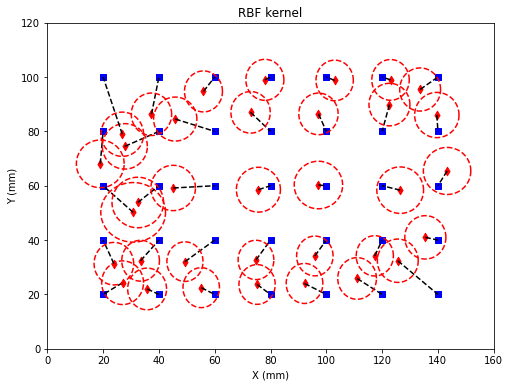

In [8]:
# visualize the results
err = print(torch.norm(mean-y_test, dim=1))
sigma = ((upper-lower)/2/1.96).detach().numpy()
theta = np.linspace(0, 2*np.pi, 73)

plt.figure(figsize=(8, 6))
plt.scatter(mean[:, 0], mean[:, 1], marker='d', color = 'r')
plt.scatter(y_test[:, 0], y_test[:, 1], marker='s', color = 'b')
for i in range(mean.shape[0]):
    plt.plot(np.array([mean[i, 0], y_test[i, 0]]), np.array([mean[i, 1], y_test[i, 1]]), 'k--')  
    plt.plot(np.cos(theta)*sigma[i, 0]+mean[i, 0].detach().numpy(), np.sin(theta)*sigma[i, 1]+mean[i, 1].detach().numpy() , 'r--')
plt.title('RBF kernel')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.xlim([0, 160])
plt.ylim([0, 120])
plt.show()